This is the start of a new project

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt, find_peaks

In [5]:
DATA_DIR = Path(r"src")
CSV_FILE = DATA_DIR / "Running trial 2.csv"

CSV_FILE = DATA_DIR / "Running trial 2.csv"
mb = 59.8
g = 9.81
BW = mb * g
m1 = 0.08 * mb
m2 = 0.92 * mb

In [6]:
print("CSV file:", CSV_FILE)
print("Body mass =", mb)
print("Body weight =", BW)
print("m1 =", m1)
print("m2 =", m2)

CSV file: src\Running trial 2.csv
Body mass = 59.8
Body weight = 586.638
m1 = 4.784
m2 = 55.016


In [7]:
df = pd.read_csv(CSV_FILE)

print("Columns:")
for c in df.columns:
    print(c)

time = df["Time"].to_numpy()
fs = round(1 / np.mean(np.diff(time)))
dt = 1 / fs

print("\nSampling frequency =", fs)


Columns:
Frame
Time
mal_lat_left_X
mal_lat_left_Y
mal_lat_left_Z
calc_back_left_X
calc_back_left_Y
calc_back_left_Z
toe_left_X
toe_left_Y
toe_left_Z
mal_lat_right_X
mal_lat_right_Y
mal_lat_right_Z
calc_back_right_X
calc_back_right_Y
calc_back_right_Z
toe_right_X
toe_right_Y
toe_right_Z
C7_X
C7_Y
C7_Z

Sampling frequency = 200


In [8]:
heelL = df["calc_back_left_Z"].to_numpy()
toeL  = df["toe_left_Z"].to_numpy()
ankL  = df["mal_lat_left_Z"].to_numpy() / 1000

heelR = df["calc_back_right_Z"].to_numpy()
toeR  = df["toe_right_Z"].to_numpy()
ankR  = df["mal_lat_right_Z"].to_numpy() / 1000

fc = 25
b, a = butter(4, fc/(fs/2), btype="low")

heelZ_L = filtfilt(b, a, heelL)
toeZ_L  = filtfilt(b, a, toeL)
ankZ_L  = filtfilt(b, a, ankL)

heelZ_R = filtfilt(b, a, heelR)
toeZ_R  = filtfilt(b, a, toeR)
ankZ_R  = filtfilt(b, a, ankR)

print("Filtering done")

Filtering done


In [9]:
locs_L, _ = find_peaks(-heelZ_L, distance=round(0.30 * fs))
locs_R, _ = find_peaks(-heelZ_R, distance=round(0.30 * fs))

print("Left touchdown candidates =", len(locs_L))
print("Right touchdown candidates =", len(locs_R))
print("Total touchdown candidates =", len(locs_L) + len(locs_R))

Left touchdown candidates = 44
Right touchdown candidates = 45
Total touchdown candidates = 89


In [10]:
toeV_L = np.gradient(toeZ_L, dt)
toeV_R = np.gradient(toeZ_R, dt)

print("Toe velocity computed")


Toe velocity computed


In [11]:
def pair_full_steps(locs, toeV, time, fs):
    TD = []
    TO = []
    nextTD = []
    tc = []
    ta = []

    for i in range(len(locs) - 1):
        td = locs[i]
        td_next = locs[i + 1]

        search_start = td + round(0.12 * fs)
        search_end = min(td + round(0.35 * fs), td_next - 1)

        if search_end <= search_start:
            continue

        seg = toeV[search_start:search_end + 1]
        idx_max = np.argmax(seg)
        to = search_start + idx_max

        TD.append(time[td])
        TO.append(time[to])
        nextTD.append(time[td_next])
        tc.append((to - td) / fs)
        ta.append((td_next - to) / fs)

    return (
        np.array(TD),
        np.array(TO),
        np.array(nextTD),
        np.array(tc),
        np.array(ta),
    )

TD_L_full, TO_L_full, nextTD_L_full, tc_L_full, ta_L_full = pair_full_steps(locs_L, toeV_L, time, fs)
TD_R_full, TO_R_full, nextTD_R_full, tc_R_full, ta_R_full = pair_full_steps(locs_R, toeV_R, time, fs)

print("Left paired steps =", len(tc_L_full))
print("Right paired steps =", len(tc_R_full))
print("Total paired steps =", len(tc_L_full) + len(tc_R_full))

Left paired steps = 43
Right paired steps = 44
Total paired steps = 87


In [12]:
T_contacts_left_full = pd.DataFrame({
    "Step": np.arange(1, len(tc_L_full) + 1),
    "Touchdown_s": TD_L_full,
    "ToeOff_s": TO_L_full,
    "NextTouchdown_s": nextTD_L_full,
    "ContactTime_s": tc_L_full,
    "AerialTime_s": ta_L_full,
})

T_contacts_right_full = pd.DataFrame({
    "Step": np.arange(1, len(tc_R_full) + 1),
    "Touchdown_s": TD_R_full,
    "ToeOff_s": TO_R_full,
    "NextTouchdown_s": nextTD_R_full,
    "ContactTime_s": tc_R_full,
    "AerialTime_s": ta_R_full,
})

T_contacts_left_full.head()


,Step,Touchdown_s,ToeOff_s,NextTouchdown_s,ContactTime_s,AerialTime_s
0,1,0.405,0.685,1.075,0.280,0.390
1,2,1.075,1.370,1.745,0.295,0.375
2,3,1.745,2.030,2.425,0.285,0.395
3,4,2.425,2.715,3.095,0.290,0.380
4,5,3.095,3.400,3.775,0.305,0.375


In [13]:
def compute_dt1(contact_df, time, ankZ, fs):
    dt1 = []

    for _, row in contact_df.iterrows():
        td_time = row["Touchdown_s"]
        to_time = row["ToeOff_s"]

        td_idx = np.argmin(np.abs(time - td_time))
        to_idx = np.argmin(np.abs(time - to_time))

        start_idx = td_idx + max(1, round(0.010 * fs))   # 10 ms after touchdown
        if to_idx <= start_idx:
            dt1.append(np.nan)
            continue

        local = ankZ[start_idx:to_idx + 1]
        idx_local_min = np.argmin(local)
        min_idx = start_idx + idx_local_min

        dt1_val = time[min_idx] - time[td_idx]
        dt1.append(dt1_val)

    return np.array(dt1)

T_contacts_left_full["dt1_s"] = compute_dt1(T_contacts_left_full, time, ankZ_L, fs)
T_contacts_right_full["dt1_s"] = compute_dt1(T_contacts_right_full, time, ankZ_R, fs)

T_contacts_left_full.head()

,Step,Touchdown_s,ToeOff_s,NextTouchdown_s,ContactTime_s,AerialTime_s,dt1_s
0,1,0.405,0.685,1.075,0.280,0.390,0.01
1,2,1.075,1.370,1.745,0.295,0.375,0.01
2,3,1.745,2.030,2.425,0.285,0.395,0.01
3,4,2.425,2.715,3.095,0.290,0.380,0.01
4,5,3.095,3.400,3.775,0.305,0.375,0.01


In [14]:
ankV_L = np.gradient(ankZ_L, dt)
ankV_R = np.gradient(ankZ_R, dt)

def compute_dv1(contact_df, time, ankV, fs):
    dv1 = []

    for _, row in contact_df.iterrows():
        td_time = row["Touchdown_s"]
        td_idx = np.argmin(np.abs(time - td_time))

        start_pre = max(0, td_idx - round(0.020 * fs))   # 20 ms before touchdown
        v_down = np.min(ankV[start_pre:td_idx + 1])

        dv1.append(abs(v_down))

    return np.array(dv1)

T_contacts_left_full["dv1_mps"] = compute_dv1(T_contacts_left_full, time, ankV_L, fs)
T_contacts_right_full["dv1_mps"] = compute_dv1(T_contacts_right_full, time, ankV_R, fs)

T_contacts_left_full.head()

,Step,Touchdown_s,ToeOff_s,NextTouchdown_s,ContactTime_s,AerialTime_s,dt1_s,dv1_mps
0,1,0.405,0.685,1.075,0.280,0.390,0.01,0.330098
1,2,1.075,1.370,1.745,0.295,0.375,0.01,0.435685
2,3,1.745,2.030,2.425,0.285,0.395,0.01,0.284125
3,4,2.425,2.715,3.095,0.290,0.380,0.01,0.228049
4,5,3.095,3.400,3.775,0.305,0.375,0.01,0.331798


In [15]:
# article: t_step = tc + ta
T_contacts_left_full["t_step_s"] = T_contacts_left_full["ContactTime_s"] + T_contacts_left_full["AerialTime_s"]
T_contacts_right_full["t_step_s"] = T_contacts_right_full["ContactTime_s"] + T_contacts_right_full["AerialTime_s"]

# JT = mb * g * t_step
T_contacts_left_full["JT_Ns"] = mb * g * T_contacts_left_full["t_step_s"]
T_contacts_right_full["JT_Ns"] = mb * g * T_contacts_right_full["t_step_s"]

# J1 = (m1 * dv1/dt1 + m1*g) * (2*dt1)
T_contacts_left_full["J1_Ns"] = (
    (m1 * (T_contacts_left_full["dv1_mps"] / T_contacts_left_full["dt1_s"])) + m1 * g
) * (2 * T_contacts_left_full["dt1_s"])

T_contacts_right_full["J1_Ns"] = (
    (m1 * (T_contacts_right_full["dv1_mps"] / T_contacts_right_full["dt1_s"])) + m1 * g
) * (2 * T_contacts_right_full["dt1_s"])

# J2 = JT - J1
T_contacts_left_full["J2_Ns"] = T_contacts_left_full["JT_Ns"] - T_contacts_left_full["J1_Ns"]
T_contacts_right_full["J2_Ns"] = T_contacts_right_full["JT_Ns"] - T_contacts_right_full["J1_Ns"]

T_contacts_left_full.head()

,Step,Touchdown_s,ToeOff_s,NextTouchdown_s,ContactTime_s,AerialTime_s,dt1_s,dv1_mps,t_step_s,JT_Ns,J1_Ns,J2_Ns
0,1,0.405,0.685,1.075,0.280,0.390,0.01,0.330098,0.67,393.04746,4.097001,388.950459
1,2,1.075,1.370,1.745,0.295,0.375,0.01,0.435685,0.67,393.04746,5.107259,387.940201
2,3,1.745,2.030,2.425,0.285,0.395,0.01,0.284125,0.68,398.91384,3.657133,395.256707
3,4,2.425,2.715,3.095,0.290,0.380,0.01,0.228049,0.67,393.04746,3.120595,389.926865
4,5,3.095,3.400,3.775,0.305,0.375,0.01,0.331798,0.68,398.91384,4.113268,394.800572


In [16]:
T_contacts_left_full["F1avg_N"] = T_contacts_left_full["J1_Ns"] / (2 * T_contacts_left_full["dt1_s"])
T_contacts_left_full["F2avg_N"] = T_contacts_left_full["J2_Ns"] / T_contacts_left_full["ContactTime_s"]
T_contacts_left_full["A1_N"] = 2 * T_contacts_left_full["F1avg_N"]

T_contacts_right_full["F1avg_N"] = T_contacts_right_full["J1_Ns"] / (2 * T_contacts_right_full["dt1_s"])
T_contacts_right_full["F2avg_N"] = T_contacts_right_full["J2_Ns"] / T_contacts_right_full["ContactTime_s"]
T_contacts_right_full["A1_N"] = 2 * T_contacts_right_full["F1avg_N"]

print("Left J2 min =", T_contacts_left_full["J2_Ns"].min())
print("Right J2 min =", T_contacts_right_full["J2_Ns"].min())

T_contacts_left_full.head()

Left J2 min = 367.6140765212706
Right J2 min = 384.77619337525533


,Step,Touchdown_s,ToeOff_s,NextTouchdown_s,ContactTime_s,AerialTime_s,dt1_s,dv1_mps,t_step_s,JT_Ns,J1_Ns,J2_Ns,F1avg_N,F2avg_N,A1_N
0,1,0.405,0.685,1.075,0.280,0.390,0.01,0.330098,0.67,393.04746,4.097001,388.950459,204.850061,1389.108781,409.700121
1,2,1.075,1.370,1.745,0.295,0.375,0.01,0.435685,0.67,393.04746,5.107259,387.940201,255.362933,1315.051530,510.725866
2,3,1.745,2.030,2.425,0.285,0.395,0.01,0.284125,0.68,398.91384,3.657133,395.256707,182.856631,1386.865640,365.713261
3,4,2.425,2.715,3.095,0.290,0.380,0.01,0.228049,0.67,393.04746,3.120595,389.926865,156.029769,1344.575395,312.059537
4,5,3.095,3.400,3.775,0.305,0.375,0.01,0.331798,0.68,398.91384,4.113268,394.800572,205.663378,1294.428106,411.326756


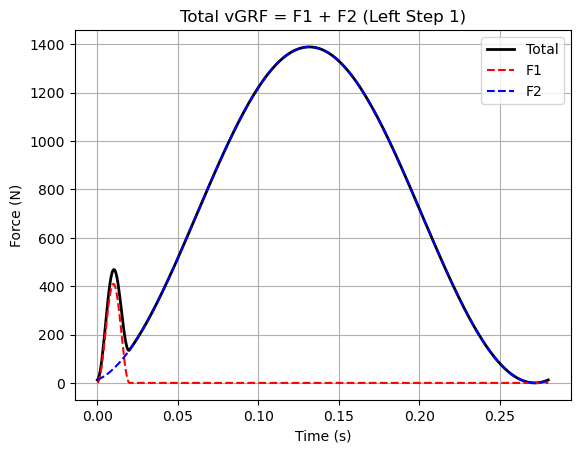

Peak total force = 1389.0966186964217


In [17]:
i = 0   # first left step

tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
dt1 = T_contacts_left_full.loc[i, "dt1_s"]

A1 = T_contacts_left_full.loc[i, "A1_N"]
A2 = T_contacts_left_full.loc[i, "F2avg_N"]   # corrected, not doubled

t = np.linspace(0, tc, 500)

# F1
B1 = dt1
C1 = dt1
F1 = np.zeros_like(t)
idx1 = (t >= 0) & (t <= 2 * dt1)
F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

# F2
B2 = 0.47 * tc
C2 = tc / 2
F2 = (A2 / 2) * (1 + np.cos(((t - B2) / C2) * np.pi))
F2[F2 < 0] = 0

FT = F1 + F2

plt.figure()
plt.plot(t, FT, 'k', linewidth=2, label='Total')
plt.plot(t, F1, '--r', label='F1')
plt.plot(t, F2, '--b', label='F2')
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.title('Total vGRF = F1 + F2 (Left Step 1)')
plt.legend()
plt.grid(True)
plt.show()

print("Peak total force =", FT.max())

In [18]:
GRF_left_full = []

for i in range(len(T_contacts_left_full)):
    tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
    dt1 = T_contacts_left_full.loc[i, "dt1_s"]

    A1 = T_contacts_left_full.loc[i, "A1_N"]
    A2 = T_contacts_left_full.loc[i, "F2avg_N"]   # corrected

    t = np.linspace(0, tc, 500)

    # F1
    B1 = dt1
    C1 = dt1
    F1 = np.zeros_like(t)
    idx1 = (t >= 0) & (t <= 2 * dt1)
    F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

    # F2
    B2 = 0.47 * tc
    C2 = tc / 2
    F2 = (A2 / 2) * (1 + np.cos(((t - B2) / C2) * np.pi))
    F2[F2 < 0] = 0

    # Total
    FT = F1 + F2

    GRF_left_full.append({
        "time": t,
        "F1": F1,
        "F2": F2,
        "FT": FT
    })

print("Left full GRF steps =", len(GRF_left_full))

Left full GRF steps = 43


In [19]:
GRF_right_full = []

for i in range(len(T_contacts_right_full)):
    tc  = T_contacts_right_full.loc[i, "ContactTime_s"]
    dt1 = T_contacts_right_full.loc[i, "dt1_s"]

    A1 = T_contacts_right_full.loc[i, "A1_N"]
    A2 = T_contacts_right_full.loc[i, "F2avg_N"]   # corrected

    t = np.linspace(0, tc, 500)

    # F1
    B1 = dt1
    C1 = dt1
    F1 = np.zeros_like(t)
    idx1 = (t >= 0) & (t <= 2 * dt1)
    F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

    # F2
    B2 = 0.47 * tc
    C2 = tc / 2
    F2 = (A2 / 2) * (1 + np.cos(((t - B2) / C2) * np.pi))
    F2[F2 < 0] = 0

    # Total
    FT = F1 + F2

    GRF_right_full.append({
        "time": t,
        "F1": F1,
        "F2": F2,
        "FT": FT
    })

print("Right full GRF steps =", len(GRF_right_full))

Right full GRF steps = 44


In [20]:
all_steps_norm = []

# LEFT
for gdict in GRF_left_full:
    f_old = np.asarray(gdict["FT"]).reshape(-1)
    x_old = np.linspace(0, 100, len(f_old))
    x_new = np.linspace(0, 100, 101)
    f_new = np.interp(x_new, x_old, f_old)
    all_steps_norm.append(f_new)

# RIGHT
for gdict in GRF_right_full:
    f_old = np.asarray(gdict["FT"]).reshape(-1)
    x_old = np.linspace(0, 100, len(f_old))
    x_new = np.linspace(0, 100, 101)
    f_new = np.interp(x_new, x_old, f_old)
    all_steps_norm.append(f_new)

GRF_norm_mat = np.column_stack(all_steps_norm)

print("Normalized matrix shape =", GRF_norm_mat.shape)

Normalized matrix shape = (101, 87)


In [21]:
x = np.linspace(0, 100, 101)

mean_norm_vgrf = GRF_norm_mat.mean(axis=1)
std_norm_vgrf = GRF_norm_mat.std(axis=1, ddof=0)

T_norm_curve = pd.DataFrame({
    "Percent_Stance": x,
    "Mean_vGRF_N": mean_norm_vgrf,
    "STD_vGRF_N": std_norm_vgrf
})

T_norm_curve.head(10)

,Percent_Stance,Mean_vGRF_N,STD_vGRF_N
0,0.0,11.139149,0.774056
1,1.0,61.415095,41.325672
2,2.0,167.832124,127.601077
3,3.0,264.929897,182.443237
4,4.0,302.231038,152.673413
5,5.0,282.039630,63.969391
6,6.0,254.311010,84.156615
7,7.0,269.496495,120.305384
8,8.0,301.505175,125.387551
9,9.0,325.644423,121.029404


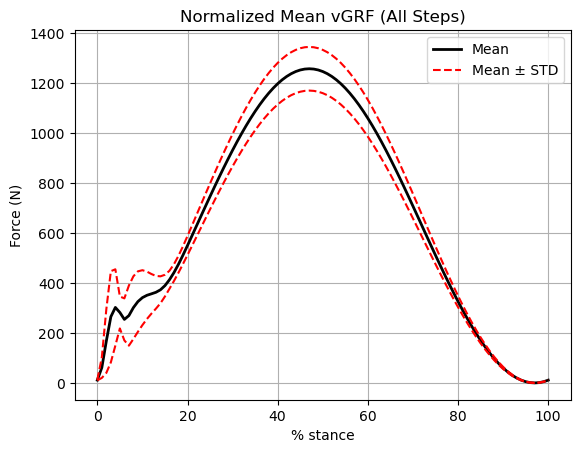

In [22]:
plt.figure()

plt.plot(x, mean_norm_vgrf, 'k', linewidth=2, label='Mean')
plt.plot(x, mean_norm_vgrf + std_norm_vgrf, '--r', label='Mean ± STD')
plt.plot(x, mean_norm_vgrf - std_norm_vgrf, '--r')

plt.xlabel('% stance')
plt.ylabel('Force (N)')
plt.title('Normalized Mean vGRF (All Steps)')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# LEFT
mean_L = np.array([g["FT"].mean() for g in GRF_left_full])
peak_L = np.array([g["FT"].max() for g in GRF_left_full])

# RIGHT
mean_R = np.array([g["FT"].mean() for g in GRF_right_full])
peak_R = np.array([g["FT"].max() for g in GRF_right_full])

T_step_summary = pd.DataFrame({
    "Step": np.r_[np.arange(1, len(mean_L)+1), np.arange(1, len(mean_R)+1)],
    "Side": ["left"]*len(mean_L) + ["right"]*len(mean_R),
    "MeanGRF": np.r_[mean_L, mean_R],
    "PeakGRF": np.r_[peak_L, peak_R]
})

T_step_summary.head()

,Step,Side,MeanGRF,PeakGRF
0,1,left,707.792839,1389.096619
1,2,left,673.512259,1315.040016
2,3,left,704.876883,1386.853497
3,4,left,681.706054,1344.563623
4,5,left,659.401816,1294.416773


In [24]:
T_contact_left = pd.DataFrame({
    "Trial": ["trial_01"] * len(T_contacts_left_full),
    "Side": ["left"] * len(T_contacts_left_full),
    "Step": T_contacts_left_full["Step"],
    "IC_Time_s": T_contacts_left_full["Touchdown_s"],
    "TO_Time_s": T_contacts_left_full["ToeOff_s"],
    "ContactTime_s": T_contacts_left_full["ContactTime_s"],
})

T_contact_right = pd.DataFrame({
    "Trial": ["trial_01"] * len(T_contacts_right_full),
    "Side": ["right"] * len(T_contacts_right_full),
    "Step": T_contacts_right_full["Step"],
    "IC_Time_s": T_contacts_right_full["Touchdown_s"],
    "TO_Time_s": T_contacts_right_full["ToeOff_s"],
    "ContactTime_s": T_contacts_right_full["ContactTime_s"],
})

T_contact_all = pd.concat([T_contact_left, T_contact_right], ignore_index=True)

In [ ]:
T_norm_curve.to_csv(SAVE_DIR / "My_Normalized_vGRF_vsc.csv", index=False)
T_step_summary.to_csv(SAVE_DIR / "My_Mean_GRF_per_Step_vsc.csv", index=False)
T_contact_all.to_csv(SAVE_DIR / "My_Contacts_vsc.csv", index=False)

print("CSV files saved")
list(SAVE_DIR.iterdir())

CSV files saved


[WindowsPath('D:/Projects/GRF_Estimation/vsc data/GRF_Final_Results_vsc.xlsx'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Contacts_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Mean_GRF_per_Step_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Normalized_vGRF_vsc.csv')]

In [ ]:
T_contacts_left_full.to_csv(SAVE_DIR / "My_Left_Input_FullSteps_vsc.csv", index=False)
T_contacts_right_full.to_csv(SAVE_DIR / "My_Right_Input_FullSteps_vsc.csv", index=False)

print("Full input CSV files saved")
list(SAVE_DIR.iterdir())

Full input CSV files saved


[WindowsPath('D:/Projects/GRF_Estimation/vsc data/GRF_Final_Results_vsc.xlsx'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Contacts_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Left_Input_FullSteps_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Mean_GRF_per_Step_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Normalized_vGRF_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Right_Input_FullSteps_vsc.csv')]

In [ ]:
from scipy.io import savemat

workspace = {
    "mean_norm_vgrf": mean_norm_vgrf,
    "std_norm_vgrf": std_norm_vgrf,
    "GRF_norm_mat": GRF_norm_mat,
    "fs": fs,
    "mb": mb,
    "BW": BW
}

savemat(SAVE_DIR / "workspace_vsc.mat", workspace)

print("MAT workspace saved")
list(SAVE_DIR.iterdir())

MAT workspace saved


[WindowsPath('D:/Projects/GRF_Estimation/vsc data/GRF_Final_Results_vsc.xlsx'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Contacts_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Left_Input_FullSteps_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Mean_GRF_per_Step_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Normalized_vGRF_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/My_Right_Input_FullSteps_vsc.csv'),
 WindowsPath('D:/Projects/GRF_Estimation/vsc data/workspace_vsc.mat')]

In [ ]:
from scipy.io import loadmat

sup = loadmat(r"D:\GRF\SR results\grf_estimates.mat")

print(sup.keys())


dict_keys(['__header__', '__version__', '__globals__', 'trials'])


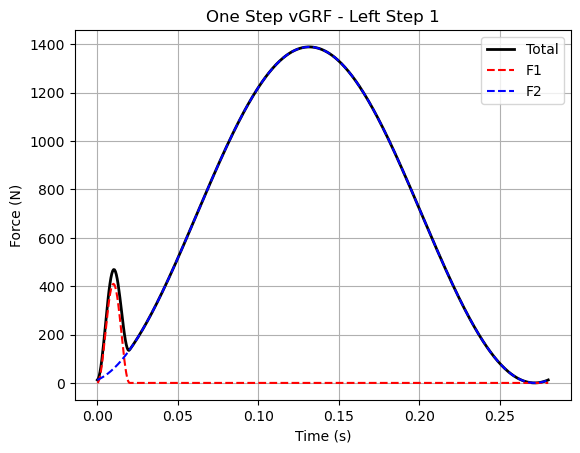

In [26]:
i = 0

plt.figure()

plt.plot(GRF_left_full[i]["time"], GRF_left_full[i]["FT"], 'k', linewidth=2, label='Total')
plt.plot(GRF_left_full[i]["time"], GRF_left_full[i]["F1"], '--r', label='F1')
plt.plot(GRF_left_full[i]["time"], GRF_left_full[i]["F2"], '--b', label='F2')

plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title("One Step vGRF - Left Step 1")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# asymmetric F2 (CORRECT)
B2 = 0.47 * tc   # peak location (from paper)

C2L = B2          # left width
C2T = tc - B2     # right width

F2 = np.zeros_like(t)

# rising phase
idxL = (t >= 0) & (t <= B2)
F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

# falling phase
idxR = (t > B2) & (t <= tc)
F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

F2[F2 < 0] = 0


In [28]:
GRF_left_full = []

for i in range(len(T_contacts_left_full)):
    tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
    dt1 = T_contacts_left_full.loc[i, "dt1_s"]

    A1 = T_contacts_left_full.loc[i, "A1_N"]
    A2 = T_contacts_left_full.loc[i, "F2avg_N"]   # corrected

    t = np.linspace(0, tc, 500)

    # F1
    B1 = dt1
    C1 = dt1
    F1 = np.zeros_like(t)
    idx1 = (t >= 0) & (t <= 2 * dt1)
    F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

    # F2 (asymmetric, corrected)
    B2 = 0.47 * tc
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

    idxR = (t > B2) & (t <= tc)
    F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

    F2[F2 < 0] = 0

    # Total
    FT = F1 + F2

    GRF_left_full.append({
        "time": t,
        "F1": F1,
        "F2": F2,
        "FT": FT
    })

print("Left full GRF steps =", len(GRF_left_full))


Left full GRF steps = 43


In [29]:
GRF_right_full = []

for i in range(len(T_contacts_right_full)):
    tc  = T_contacts_right_full.loc[i, "ContactTime_s"]
    dt1 = T_contacts_right_full.loc[i, "dt1_s"]

    A1 = T_contacts_right_full.loc[i, "A1_N"]
    A2 = T_contacts_right_full.loc[i, "F2avg_N"]   # corrected

    t = np.linspace(0, tc, 500)

    # F1
    B1 = dt1
    C1 = dt1
    F1 = np.zeros_like(t)
    idx1 = (t >= 0) & (t <= 2 * dt1)
    F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

    # F2 (asymmetric, corrected)
    B2 = 0.47 * tc
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

    idxR = (t > B2) & (t <= tc)
    F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

    F2[F2 < 0] = 0

    # Total
    FT = F1 + F2

    GRF_right_full.append({
        "time": t,
        "F1": F1,
        "F2": F2,
        "FT": FT
    })

print("Right full GRF steps =", len(GRF_right_full))

Right full GRF steps = 44


In [30]:
all_steps_norm = []

# LEFT
for gdict in GRF_left_full:
    f_old = np.asarray(gdict["FT"]).reshape(-1)
    x_old = np.linspace(0, 100, len(f_old))
    x_new = np.linspace(0, 100, 101)
    f_new = np.interp(x_new, x_old, f_old)
    all_steps_norm.append(f_new)

# RIGHT
for gdict in GRF_right_full:
    f_old = np.asarray(gdict["FT"]).reshape(-1)
    x_old = np.linspace(0, 100, len(f_old))
    x_new = np.linspace(0, 100, 101)
    f_new = np.interp(x_new, x_old, f_old)
    all_steps_norm.append(f_new)

GRF_norm_mat = np.column_stack(all_steps_norm)

print("Normalized matrix shape =", GRF_norm_mat.shape)


Normalized matrix shape = (101, 87)


In [31]:
x = np.linspace(0, 100, 101)

mean_norm_vgrf = GRF_norm_mat.mean(axis=1)
std_norm_vgrf = GRF_norm_mat.std(axis=1, ddof=0)

print("Peak mean force =", mean_norm_vgrf.max())

Peak mean force = 1257.7422577162781


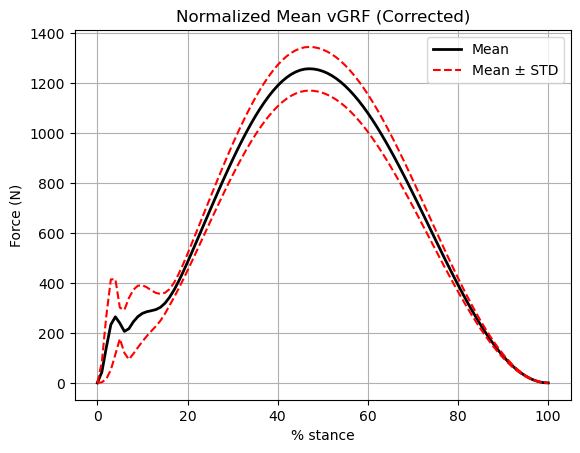

In [32]:
plt.figure()

plt.plot(x, mean_norm_vgrf, 'k', linewidth=2, label='Mean')
plt.plot(x, mean_norm_vgrf + std_norm_vgrf, '--r', label='Mean ± STD')
plt.plot(x, mean_norm_vgrf - std_norm_vgrf, '--r')

plt.xlabel('% stance')
plt.ylabel('Force (N)')
plt.title('Normalized Mean vGRF (Corrected)')
plt.legend()
plt.grid(True)
plt.show()

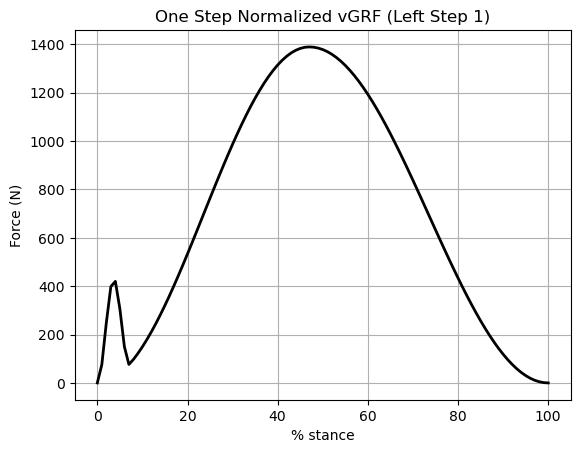

Peak = 1389.0948175376004


In [33]:
i = 0   # first left step

f_old = np.asarray(GRF_left_full[i]["FT"]).reshape(-1)

x_old = np.linspace(0, 100, len(f_old))
x_new = np.linspace(0, 100, 101)

f_norm = np.interp(x_new, x_old, f_old)

plt.figure()
plt.plot(x_new, f_norm, 'k', linewidth=2)

plt.xlabel('% stance')
plt.ylabel('Force (N)')
plt.title('One Step Normalized vGRF (Left Step 1)')
plt.grid(True)
plt.show()

print("Peak =", f_norm.max())

In [1]:
from scipy.io import loadmat
import numpy as np

sup = loadmat(r"D:\GRF\SR results\grf_estimates.mat", simplify_cells=True)

step1 = sup["trials"]["trial_01"]["forceplate"]["left"][0]

print(step1.keys())
print("\nforceplate_truth_3d keys:")
print(step1["forceplate_truth_3d"].keys())
print("\nforceplate_truth_3d_bw keys:")
print(step1["forceplate_truth_3d_bw"].keys())

dict_keys(['window', 'forceplate_truth_3d', 'forceplate_truth_3d_bw', 'com_grf_3d', 'com_grf_3d_bw', 'two_mass_vgrf', 'two_mass_vgrf_bw', 'duty_factor_impulse_raw', 'duty_factor_impulse_bw', 'metadata'])

forceplate_truth_3d keys:
dict_keys(['raw', 'normalized', 'time_s', 'normalized_time', 'units'])

forceplate_truth_3d_bw keys:
dict_keys(['raw', 'normalized', 'time_s', 'normalized_time', 'units'])


Raw force length = 1464
Number of samples above 40 N = 695
First index above 40 N = 2
Last index above 40 N = 1463


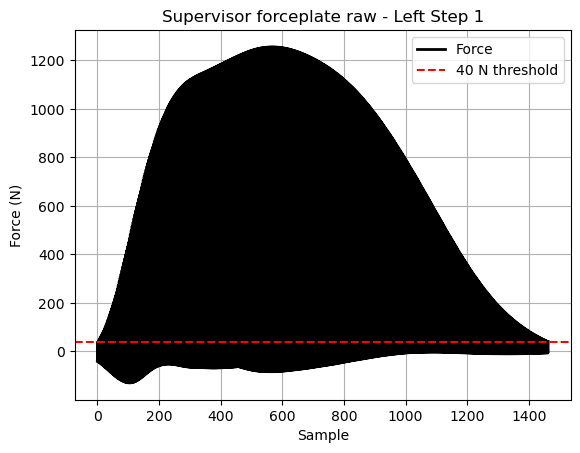

In [3]:
f_raw = np.asarray(step1["forceplate_truth_3d"]["raw"]).reshape(-1)

contact_idx = np.where(f_raw > 40)[0]

print("Raw force length =", len(f_raw))
print("Number of samples above 40 N =", len(contact_idx))
print("First index above 40 N =", contact_idx[0])
print("Last index above 40 N =", contact_idx[-1])

plt.figure()
plt.plot(f_raw, 'k', linewidth=2, label='Force')
plt.axhline(40, color='r', linestyle='--', label='40 N threshold')
plt.xlabel('Sample')
plt.ylabel('Force (N)')
plt.title('Supervisor forceplate raw - Left Step 1')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
F3D = np.asarray(step1["forceplate_truth_3d"]["raw"])

print("Shape of raw force =", F3D.shape)

Shape of raw force = (488, 3)


Fz length = 488
Samples above 40 N = 488
First index above 40 N = 0
Last index above 40 N = 487


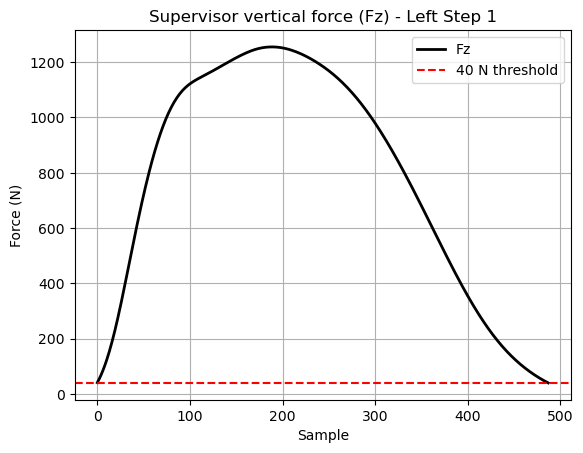

In [5]:
Fz = F3D[:, 2]

contact_idx = np.where(Fz > 40)[0]

print("Fz length =", len(Fz))
print("Samples above 40 N =", len(contact_idx))
print("First index above 40 N =", contact_idx[0])
print("Last index above 40 N =", contact_idx[-1])

plt.figure()
plt.plot(Fz, 'k', linewidth=2, label='Fz')
plt.axhline(40, color='r', linestyle='--', label='40 N threshold')
plt.xlabel('Sample')
plt.ylabel('Force (N)')
plt.title('Supervisor vertical force (Fz) - Left Step 1')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
contact_start = contact_idx[0]
contact_end = contact_idx[-1]

Fz_contact = Fz[contact_start:contact_end+1]

print("Contact samples =", len(Fz_contact))

Contact samples = 488


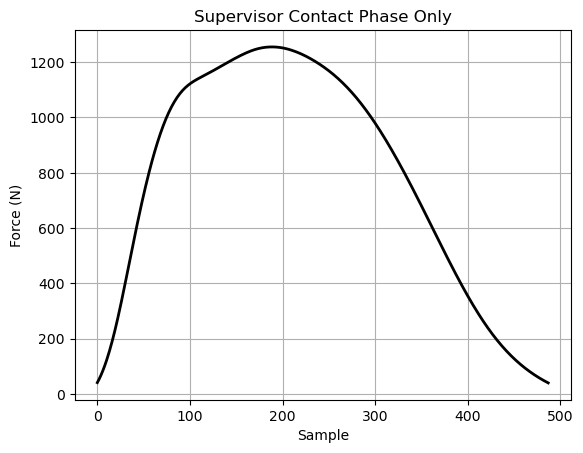

In [7]:
plt.figure()
plt.plot(Fz_contact, 'k', linewidth=2)
plt.xlabel('Sample')
plt.ylabel('Force (N)')
plt.title('Supervisor Contact Phase Only')
plt.grid(True)
plt.show()

In [8]:
contact_start = contact_idx[0]
contact_end = contact_idx[-1]

Fz_contact = Fz[contact_start:contact_end+1]

print("Contact samples =", len(Fz_contact))

Contact samples = 488


In [9]:
x_old_ref = np.linspace(0, 100, len(Fz_contact))
x_new_ref = np.linspace(0, 100, 101)

Fz_contact_norm = np.interp(x_new_ref, x_old_ref, Fz_contact)

print("Normalized reference shape =", Fz_contact_norm.shape)
print("Reference peak =", Fz_contact_norm.max())

Normalized reference shape = (101,)
Reference peak = 1255.0487283943837


In [12]:
import pandas as pd
import numpy as np

# load your saved left input file
T_contacts_left_full = pd.read_csv(r"D:\Projects\GRF_Estimation\vsc data/My_Left_Input_FullSteps_vsc.csv")

print(T_contacts_left_full.columns)
print("Number of steps =", len(T_contacts_left_full))

Index(['Step', 'Touchdown_s', 'ToeOff_s', 'NextTouchdown_s', 'ContactTime_s',
       'AerialTime_s', 'dt1_s', 'dv1_mps', 't_step_s', 'JT_Ns', 'J1_Ns',
       'J2_Ns', 'F1avg_N', 'F2avg_N', 'A1_N'],
      dtype='object')
Number of steps = 43


In [13]:
GRF_left_full = []

for i in range(len(T_contacts_left_full)):
    tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
    dt1 = T_contacts_left_full.loc[i, "dt1_s"]

    A1 = T_contacts_left_full.loc[i, "A1_N"]
    A2 = T_contacts_left_full.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # F1
    B1 = dt1
    C1 = dt1
    F1 = np.zeros_like(t)
    idx1 = (t >= 0) & (t <= 2 * dt1)
    F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

    # F2 asymmetric
    B2 = 0.47 * tc
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

    idxR = (t > B2) & (t <= tc)
    F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

    F2[F2 < 0] = 0

    FT = F1 + F2

    GRF_left_full.append({"FT": FT})

print("Left GRF rebuilt =", len(GRF_left_full))

Left GRF rebuilt = 43


In [14]:
# normalize your first predicted step to 101 points
pred_step = np.asarray(GRF_left_full[0]["FT"]).reshape(-1)

x_old_pred = np.linspace(0, 100, len(pred_step))
x_new_pred = np.linspace(0, 100, 101)

pred_step_norm = np.interp(x_new_pred, x_old_pred, pred_step)

print("Predicted normalized shape =", pred_step_norm.shape)
print("Predicted peak =", pred_step_norm.max())

Predicted normalized shape = (101,)
Predicted peak = 1389.0948175376002


In [15]:
rmse_step1 = np.sqrt(np.mean((pred_step_norm - Fz_contact_norm) ** 2))

print("RMSE (Step 1) =", rmse_step1)

RMSE (Step 1) = 274.6339496966072


In [16]:
# apply 40 N threshold to predicted step
threshold = 40

idx_pred = np.where(pred_step > threshold)[0]

print("Samples above 40 N (predicted) =", len(idx_pred))
print("Start index =", idx_pred[0])
print("End index =", idx_pred[-1])

Samples above 40 N (predicted) = 467
Start index = 4
End index = 470


In [17]:
pred_contact = pred_step[idx_pred[0]:idx_pred[-1] + 1]

print("Predicted contact samples =", len(pred_contact))


Predicted contact samples = 467


In [18]:
x_old_pred_contact = np.linspace(0, 100, len(pred_contact))
x_new = np.linspace(0, 100, 101)

pred_contact_norm = np.interp(x_new, x_old_pred_contact, pred_contact)

print("Predicted contact normalized shape =", pred_contact_norm.shape)
print("Predicted contact peak =", pred_contact_norm.max())

Predicted contact normalized shape = (101,)
Predicted contact peak = 1388.8098400705642


In [19]:
rmse_step1_thresh40 = np.sqrt(np.mean((pred_contact_norm - Fz_contact_norm) ** 2))

print("RMSE with 40 N threshold (Step 1) =", rmse_step1_thresh40)

RMSE with 40 N threshold (Step 1) = 306.49419229120775


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# first predicted left step
pred_step = np.asarray(GRF_left_full[0]["FT"]).reshape(-1)

threshold = 40
idx_pred = np.where(pred_step > threshold)[0]

pred_contact = pred_step[idx_pred[0]:idx_pred[-1] + 1]

x_old = np.linspace(0, 100, len(pred_contact))
x_new = np.linspace(0, 100, 101)

pred_contact_norm = np.interp(x_new, x_old, pred_contact)

print("Original predicted samples =", len(pred_step))
print("Predicted contact samples =", len(pred_contact))
print("Corrected predicted peak =", pred_contact_norm.max())

Original predicted samples = 500
Predicted contact samples = 467
Corrected predicted peak = 1388.8098400705642


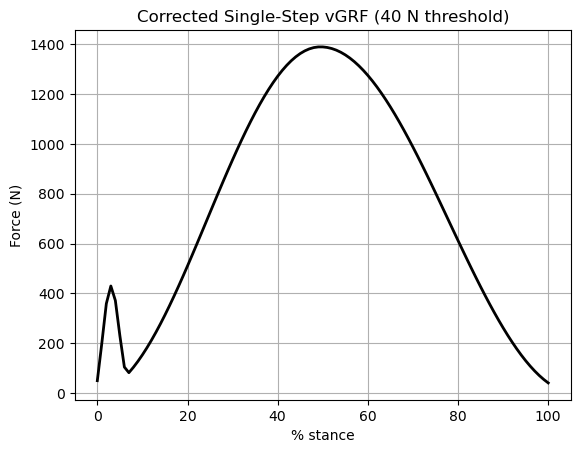

In [21]:
plt.figure()

plt.plot(x_new, pred_contact_norm, 'k', linewidth=2)

plt.xlabel('% stance')
plt.ylabel('Force (N)')
plt.title('Corrected Single-Step vGRF (40 N threshold)')
plt.grid(True)
plt.show()

In [22]:
step1_model = sup["trials"]["trial_01"]["forceplate"]["left"][0]

sup_two_mass = np.asarray(step1_model["two_mass_vgrf"]["normalized"]).reshape(-1)
sup_two_mass_bw = np.asarray(step1_model["two_mass_vgrf_bw"]["normalized"]).reshape(-1)

print("Supervisor two-mass shape =", sup_two_mass.shape)
print("Supervisor two-mass BW shape =", sup_two_mass_bw.shape)
print("Supervisor two-mass peak (N) =", sup_two_mass.max())

Supervisor two-mass shape = (101,)
Supervisor two-mass BW shape = (101,)
Supervisor two-mass peak (N) = 1626.8049245078273


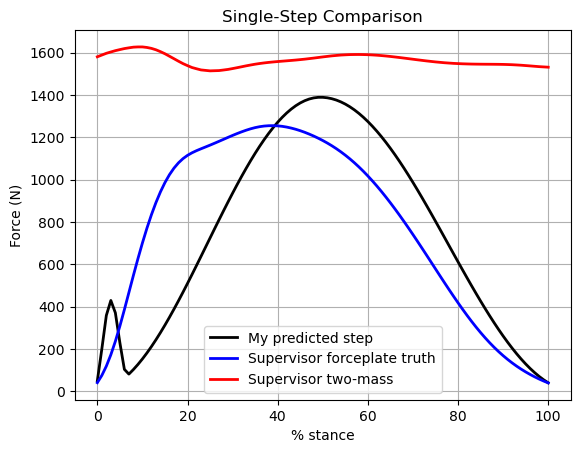

In [23]:
plt.figure()

plt.plot(x_new, pred_contact_norm, 'k', linewidth=2, label='My predicted step')
plt.plot(x_new_ref, Fz_contact_norm, 'b', linewidth=2, label='Supervisor forceplate truth')
plt.plot(x_new, sup_two_mass, 'r', linewidth=2, label='Supervisor two-mass')

plt.xlabel('% stance')
plt.ylabel('Force (N)')
plt.title('Single-Step Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat

# your saved step table
my_left = pd.read_csv(r"D:\Projects\GRF_Estimation\vsc data\My_Left_Input_FullSteps_vsc.csv")

# supervisor mat
sup = loadmat(r"D:\GRF\SR results\grf_estimates.mat", simplify_cells=True)
sup_step = sup["trials"]["trial_01"]["forceplate"]["left"][0]

# supervisor one-step signals
sup_force = np.asarray(sup_step["forceplate_truth_3d"]["raw"])
sup_fz = sup_force[:, 2].reshape(-1)

sup_model = np.asarray(sup_step["two_mass_vgrf"]["normalized"]).reshape(-1)

# supervisor contact duration from 40 N threshold
sup_idx = np.where(sup_fz > 40)[0]
sup_tc_samples = sup_idx[-1] - sup_idx[0] + 1

# your first step values
my_step1 = my_left.iloc[0]

compare_table = pd.DataFrame({
    "Quantity": [
        "My tc (s)",
        "My ta (s)",
        "My dt1 (s)",
        "My dv1 (m/s)",
        "My JT (Ns)",
        "My J1 (Ns)",
        "My J2 (Ns)",
        "Supervisor contact samples (>40 N)",
        "Supervisor forceplate peak (N)",
        "Supervisor two-mass peak (N)"
    ],
    "Value": [
        my_step1["ContactTime_s"],
        my_step1["AerialTime_s"],
        my_step1["dt1_s"],
        my_step1["dv1_mps"],
        my_step1["JT_Ns"],
        my_step1["J1_Ns"],
        my_step1["J2_Ns"],
        sup_tc_samples,
        sup_fz.max(),
        sup_model.max()
    ]
})

compare_table

,Quantity,Value
0,My tc (s),0.280000
1,My ta (s),0.390000
2,My dt1 (s),0.010000
3,My dv1 (m/s),0.330098
4,My JT (Ns),393.047460
5,My J1 (Ns),4.097001
6,My J2 (Ns),388.950459
7,Supervisor contact samples (>40 N),488.000000
8,Supervisor forceplate peak (N),1255.095258
9,Supervisor two-mass peak (N),1626.804925


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load your original CSV again
df = pd.read_csv(r"D:\GRF\data csv\Running trial 2.csv")  # ⚠️ replace with your actual file name

time = df["Time"].values
ankZ_L = df["mal_lat_left_Z"].values

print("Data loaded:", len(time))

Data loaded: 6000


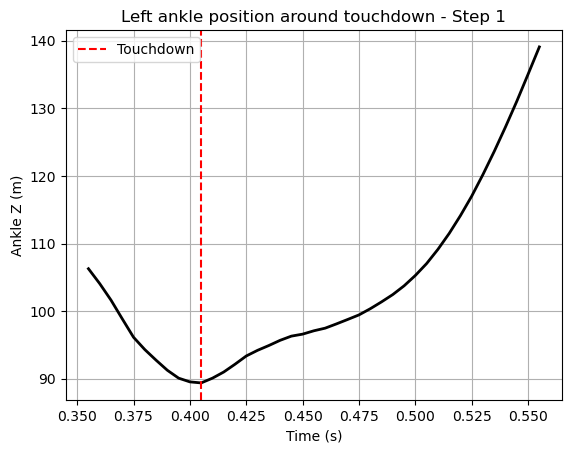

Touchdown index = 81
Toe-off index = 137
Current dt1 = 0.0099999999999999


In [5]:
td_time = my_step1["Touchdown_s"]
to_time = my_step1["ToeOff_s"]

td_idx = np.argmin(np.abs(time - td_time))
to_idx = np.argmin(np.abs(time - to_time))

start_idx = max(0, td_idx - 10)
end_idx = min(len(time) - 1, td_idx + 30)

plt.figure()
plt.plot(time[start_idx:end_idx+1], ankZ_L[start_idx:end_idx+1], 'k', linewidth=2)
plt.axvline(time[td_idx], color='r', linestyle='--', label='Touchdown')
plt.xlabel('Time (s)')
plt.ylabel('Ankle Z (m)')
plt.title('Left ankle position around touchdown - Step 1')
plt.legend()
plt.grid(True)
plt.show()

print("Touchdown index =", td_idx)
print("Toe-off index =", to_idx)
print("Current dt1 =", my_step1['dt1_s'])

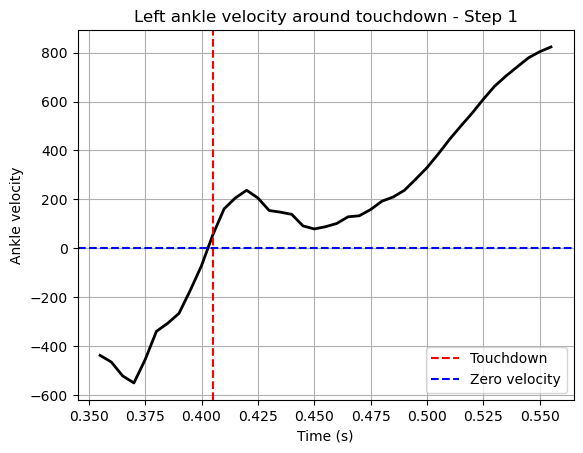

In [6]:
ankV_L = np.gradient(ankZ_L, np.mean(np.diff(time)))

start_idx = max(0, td_idx - 10)
end_idx = min(len(time) - 1, td_idx + 30)

plt.figure()
plt.plot(time[start_idx:end_idx+1], ankV_L[start_idx:end_idx+1], 'k', linewidth=2)
plt.axvline(time[td_idx], color='r', linestyle='--', label='Touchdown')
plt.axhline(0, color='b', linestyle='--', label='Zero velocity')
plt.xlabel('Time (s)')
plt.ylabel('Ankle velocity')
plt.title('Left ankle velocity around touchdown - Step 1')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import pandas as pd

T_contacts_left_full = pd.read_csv(r"D:\Projects\GRF_Estimation\vsc data\My_Left_Input_FullSteps_vsc.csv")
T_contacts_right_full = pd.read_csv(r"D:\Projects\GRF_Estimation\vsc data\My_Right_Input_FullSteps_vsc.csv")

print("Left steps =", len(T_contacts_left_full))
print("Right steps =", len(T_contacts_right_full))
print(T_contacts_left_full.columns)

Left steps = 43
Right steps = 44
Index(['Step', 'Touchdown_s', 'ToeOff_s', 'NextTouchdown_s', 'ContactTime_s',
       'AerialTime_s', 'dt1_s', 'dv1_mps', 't_step_s', 'JT_Ns', 'J1_Ns',
       'J2_Ns', 'F1avg_N', 'F2avg_N', 'A1_N'],
      dtype='object')


In [9]:
T_contacts_left_full["dt1_s"] = 0.03
T_contacts_right_full["dt1_s"] = 0.03

print(T_contacts_left_full[["Step", "dt1_s"]].head())
print(T_contacts_right_full[["Step", "dt1_s"]].head())

   Step  dt1_s
0     1   0.03
1     2   0.03
2     3   0.03
3     4   0.03
4     5   0.03
   Step  dt1_s
0     1   0.03
1     2   0.03
2     3   0.03
3     4   0.03
4     5   0.03


In [10]:
mb = 59.8
g = 9.81
m1 = 0.08 * mb

# LEFT
T_contacts_left_full["J1_Ns"] = (
    (m1 * (T_contacts_left_full["dv1_mps"] / T_contacts_left_full["dt1_s"])) + m1 * g
) * (2 * T_contacts_left_full["dt1_s"])

T_contacts_left_full["J2_Ns"] = T_contacts_left_full["JT_Ns"] - T_contacts_left_full["J1_Ns"]
T_contacts_left_full["F1avg_N"] = T_contacts_left_full["J1_Ns"] / (2 * T_contacts_left_full["dt1_s"])
T_contacts_left_full["A1_N"] = 2 * T_contacts_left_full["F1avg_N"]

# RIGHT
T_contacts_right_full["J1_Ns"] = (
    (m1 * (T_contacts_right_full["dv1_mps"] / T_contacts_right_full["dt1_s"])) + m1 * g
) * (2 * T_contacts_right_full["dt1_s"])

T_contacts_right_full["J2_Ns"] = T_contacts_right_full["JT_Ns"] - T_contacts_right_full["J1_Ns"]
T_contacts_right_full["F1avg_N"] = T_contacts_right_full["J1_Ns"] / (2 * T_contacts_right_full["dt1_s"])
T_contacts_right_full["A1_N"] = 2 * T_contacts_right_full["F1avg_N"]

print(T_contacts_left_full[["Step","dt1_s","dv1_mps","J1_Ns","J2_Ns","F1avg_N","A1_N"]].head())

   Step  dt1_s   dv1_mps     J1_Ns       J2_Ns     F1avg_N        A1_N
0     1   0.03  0.330098  5.974243  387.073217   99.570714  199.141427
1     2   0.03  0.435685  6.984500  386.062960  116.408338  232.816675
2     3   0.03  0.284125  5.534374  393.379466   92.239570  184.479140
3     4   0.03  0.228049  4.997837  388.049623   83.297283  166.594566
4     5   0.03  0.331798  5.990509  392.923331   99.841819  199.683639


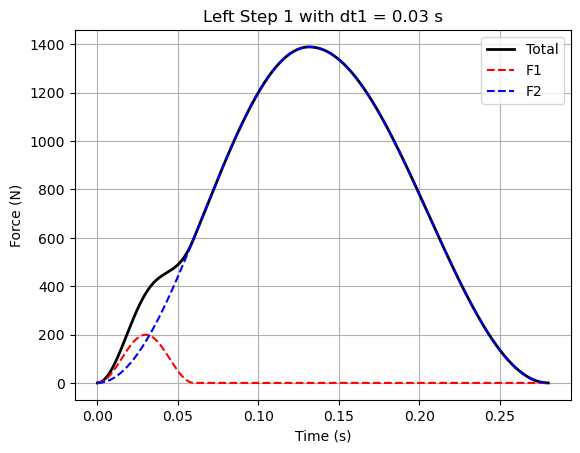

Peak total force = 1389.0979566312874


In [11]:
import numpy as np
import matplotlib.pyplot as plt

i = 0

tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
dt1 = T_contacts_left_full.loc[i, "dt1_s"]

A1 = T_contacts_left_full.loc[i, "A1_N"]
A2 = T_contacts_left_full.loc[i, "F2avg_N"]

t = np.linspace(0, tc, 500)

# F1
B1 = dt1
C1 = dt1
F1 = np.zeros_like(t)
idx1 = (t >= 0) & (t <= 2 * dt1)
F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

# F2 asymmetric
B2 = 0.47 * tc
C2L = B2
C2T = tc - B2

F2 = np.zeros_like(t)

idxL = (t >= 0) & (t <= B2)
F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

idxR = (t > B2) & (t <= tc)
F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

F2[F2 < 0] = 0

FT = F1 + F2

plt.figure()
plt.plot(t, FT, 'k', linewidth=2, label='Total')
plt.plot(t, F1, '--r', label='F1')
plt.plot(t, F2, '--b', label='F2')
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.title('Left Step 1 with dt1 = 0.03 s')
plt.legend()
plt.grid(True)
plt.show()

print("Peak total force =", FT.max())

In [12]:
dt1 = 0.04

In [13]:
T_contacts_left_full["dt1_s"] = 0.04
T_contacts_right_full["dt1_s"] = 0.04

In [14]:
T_contacts_left_full["dt1_s"] = 0.04
T_contacts_right_full["dt1_s"] = 0.04

print(T_contacts_left_full[["Step", "dt1_s"]].head())
print(T_contacts_right_full[["Step", "dt1_s"]].head())

   Step  dt1_s
0     1   0.04
1     2   0.04
2     3   0.04
3     4   0.04
4     5   0.04
   Step  dt1_s
0     1   0.04
1     2   0.04
2     3   0.04
3     4   0.04
4     5   0.04


In [15]:
mb = 59.8
g = 9.81
m1 = 0.08 * mb

# LEFT
T_contacts_left_full["J1_Ns"] = (
    (m1 * (T_contacts_left_full["dv1_mps"] / T_contacts_left_full["dt1_s"])) + m1 * g
) * (2 * T_contacts_left_full["dt1_s"])

T_contacts_left_full["J2_Ns"] = T_contacts_left_full["JT_Ns"] - T_contacts_left_full["J1_Ns"]
T_contacts_left_full["F1avg_N"] = T_contacts_left_full["J1_Ns"] / (2 * T_contacts_left_full["dt1_s"])
T_contacts_left_full["A1_N"] = 2 * T_contacts_left_full["F1avg_N"]

# RIGHT
T_contacts_right_full["J1_Ns"] = (
    (m1 * (T_contacts_right_full["dv1_mps"] / T_contacts_right_full["dt1_s"])) + m1 * g
) * (2 * T_contacts_right_full["dt1_s"])

T_contacts_right_full["J2_Ns"] = T_contacts_right_full["JT_Ns"] - T_contacts_right_full["J1_Ns"]
T_contacts_right_full["F1avg_N"] = T_contacts_right_full["J1_Ns"] / (2 * T_contacts_right_full["dt1_s"])
T_contacts_right_full["A1_N"] = 2 * T_contacts_right_full["F1avg_N"]

print(T_contacts_left_full[["Step","dt1_s","dv1_mps","J1_Ns","J2_Ns","F1avg_N","A1_N"]].head())

   Step  dt1_s   dv1_mps     J1_Ns       J2_Ns    F1avg_N        A1_N
0     1   0.04  0.330098  6.912864  386.134596  86.410795  172.821590
1     2   0.04  0.435685  7.923121  385.124339  99.039013  198.078027
2     3   0.04  0.284125  6.472995  392.440845  80.912438  161.824875
3     4   0.04  0.228049  5.936458  387.111002  74.205722  148.411444
4     5   0.04  0.331798  6.929130  391.984710  86.614125  173.228249


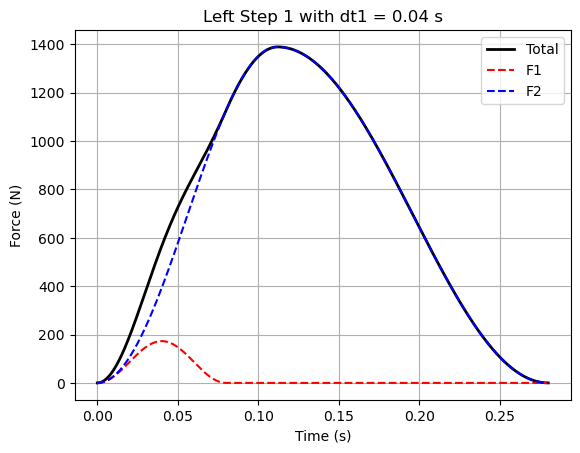

Peak total force = 1389.1026636280856


In [23]:
import numpy as np
import matplotlib.pyplot as plt

i = 0

tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
dt1 = T_contacts_left_full.loc[i, "dt1_s"]

A1 = T_contacts_left_full.loc[i, "A1_N"]
A2 = T_contacts_left_full.loc[i, "F2avg_N"]

t = np.linspace(0, tc, 500)

# F1
B1 = dt1
C1 = dt1
F1 = np.zeros_like(t)
idx1 = (t >= 0) & (t <= 2 * dt1)
F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

# F2 asymmetric
B2 = 0.40 * tc
C2L = B2
C2T = tc - B2

F2 = np.zeros_like(t)

idxL = (t >= 0) & (t <= B2)
F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

idxR = (t > B2) & (t <= tc)
F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

F2[F2 < 0] = 0

FT = F1 + F2

plt.figure()
plt.plot(t, FT, 'k', linewidth=2, label='Total')
plt.plot(t, F1, '--r', label='F1')
plt.plot(t, F2, '--b', label='F2')
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.title('Left Step 1 with dt1 = 0.04 s')
plt.legend()
plt.grid(True)
plt.show()

print("Peak total force =", FT.max())

In [17]:
# apply threshold to new FT
threshold = 40

idx_pred = np.where(FT > threshold)[0]

pred_contact = FT[idx_pred[0]:idx_pred[-1] + 1]

print("Predicted contact samples =", len(pred_contact))
print("Start index =", idx_pred[0])
print("End index =", idx_pred[-1])

Predicted contact samples = 454
Start index = 17
End index = 470


In [19]:
import numpy as np
from scipy.io import loadmat

# reload supervisor reference
sup = loadmat(r"D:\GRF\SR results\grf_estimates.mat", simplify_cells=True)
step1 = sup["trials"]["trial_01"]["forceplate"]["left"][0]

F3D = np.asarray(step1["forceplate_truth_3d"]["raw"])
Fz = F3D[:, 2]

# 40 N threshold
idx_ref = np.where(Fz > 40)[0]
Fz_contact = Fz[idx_ref[0]:idx_ref[-1] + 1]

# normalize reference
x_old_ref = np.linspace(0, 100, len(Fz_contact))
x_new = np.linspace(0, 100, 101)

Fz_contact_norm = np.interp(x_new, x_old_ref, Fz_contact)

# normalize predicted (already computed pred_contact)
x_old_pred = np.linspace(0, 100, len(pred_contact))
pred_contact_norm = np.interp(x_new, x_old_pred, pred_contact)

# RMSE
rmse_final = np.sqrt(np.mean((pred_contact_norm - Fz_contact_norm) ** 2))

print("Final RMSE (dt1 = 0.04) =", rmse_final)
print("Predicted peak =", pred_contact_norm.max())
print("Reference peak =", Fz_contact_norm.max())

Final RMSE (dt1 = 0.04) = 221.09048680318983
Predicted peak = 1389.0942164345536
Reference peak = 1255.0487283943837


In [20]:
import pandas as pd
from pathlib import Path

save_dir = Path(r"D:\Projects\GRF_Estimation\vsc data")
save_dir.mkdir(parents=True, exist_ok=True)

summary_corrected = pd.DataFrame({
    "Metric": ["Final_RMSE_dt1_0p04", "Predicted_Peak_N", "Reference_Peak_N"],
    "Value": [rmse_final, pred_contact_norm.max(), Fz_contact_norm.max()]
})

summary_corrected.to_csv(save_dir / "Final_RMSE_Corrected.csv", index=False)

print("Saved:", save_dir / "Final_RMSE_Corrected.csv")

Saved: D:\Projects\GRF_Estimation\vsc data\Final_RMSE_Corrected.csv


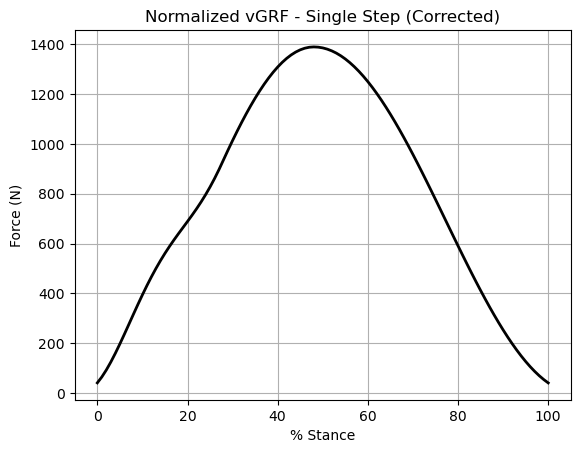

Peak force = 1389.0942164345536


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# -------- STEP 1: build one predicted step (already FT from your last step) --------
# (make sure FT is from dt1 = 0.04 step)

threshold = 40

# -------- STEP 2: apply 40 N threshold --------
idx = np.where(FT > threshold)[0]
pred_contact = FT[idx[0]:idx[-1] + 1]

# -------- STEP 3: normalize to 101 points --------
x_old = np.linspace(0, 100, len(pred_contact))
x_new = np.linspace(0, 100, 101)

pred_norm = np.interp(x_new, x_old, pred_contact)

# -------- STEP 4: plot --------
plt.figure()
plt.plot(x_new, pred_norm, 'k', linewidth=2)

plt.xlabel('% Stance')
plt.ylabel('Force (N)')
plt.title('Normalized vGRF - Single Step (Corrected)')
plt.grid(True)
plt.show()

# -------- STEP 5: print values --------
print("Peak force =", pred_norm.max())

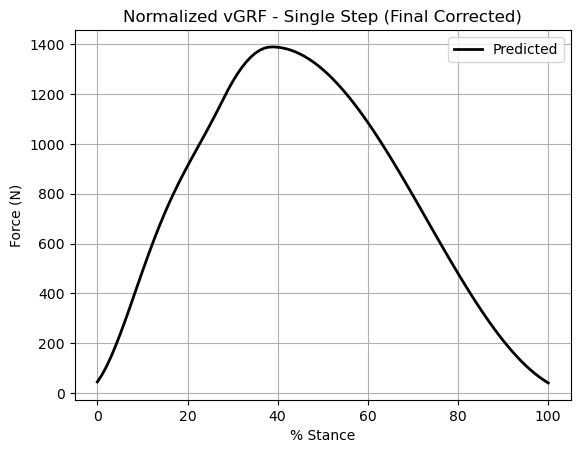

Peak force = 1389.025778320491


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# -------- Step index --------
i = 0   # first left step

# -------- Load values --------
tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
dt1 = 0.04   # fixed impact duration

A1 = T_contacts_left_full.loc[i, "A1_N"]
A2 = T_contacts_left_full.loc[i, "F2avg_N"]

# -------- Time vector --------
t = np.linspace(0, tc, 500)

# -------- F1 (impact) --------
B1 = dt1
C1 = dt1

F1 = np.zeros_like(t)
idx1 = (t >= 0) & (t <= 2 * dt1)

F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

# -------- F2 (active force) --------
# 🔥 corrected peak shift
B2 = 0.38 * tc
C2L = B2
C2T = tc - B2

F2 = np.zeros_like(t)

idxL = (t >= 0) & (t <= B2)
F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

idxR = (t > B2) & (t <= tc)
F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

F2[F2 < 0] = 0

# -------- Total GRF --------
FT = F1 + F2

# -------- Apply 40 N threshold --------
threshold = 40
idx = np.where(FT > threshold)[0]
pred_contact = FT[idx[0]:idx[-1] + 1]

# -------- Normalize --------
x_old = np.linspace(0, 100, len(pred_contact))
x_new = np.linspace(0, 100, 101)

pred_norm = np.interp(x_new, x_old, pred_contact)

# -------- Plot --------
plt.figure()
plt.plot(x_new, pred_norm, 'k', linewidth=2, label='Predicted')

# optional: compare with reference
# plt.plot(x_new, Fz_contact_norm, 'b', label='Forceplate')

plt.xlabel('% Stance')
plt.ylabel('Force (N)')
plt.title('Normalized vGRF - Single Step (Final Corrected)')
plt.legend()
plt.grid(True)
plt.show()

# -------- Output --------
print("Peak force =", pred_norm.max())

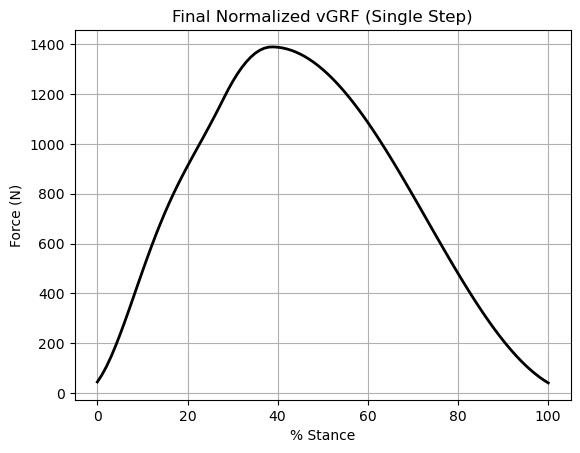

Peak = 1389.025778320491


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


i = 0  # first step

tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
dt1 = 0.04

A1 = T_contacts_left_full.loc[i, "A1_N"]
A2 = T_contacts_left_full.loc[i, "F2avg_N"]

t = np.linspace(0, tc, 500)

# -------- F1 --------
B1 = dt1
C1 = dt1

F1 = np.zeros_like(t)
idx1 = (t >= 0) & (t <= 2 * dt1)
F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

# -------- F2 --------
B2 = 0.38 * tc   # 🔥 FINAL VALUE
C2L = B2
C2T = tc - B2

F2 = np.zeros_like(t)

idxL = (t >= 0) & (t <= B2)
F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

idxR = (t > B2) & (t <= tc)
F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

F2[F2 < 0] = 0

FT = F1 + F2

# -------- Threshold --------
idx = np.where(FT > 40)[0]
pred_contact = FT[idx[0]:idx[-1] + 1]

# -------- Normalize --------
x_old = np.linspace(0, 100, len(pred_contact))
x_new = np.linspace(0, 100, 101)

pred_norm = np.interp(x_new, x_old, pred_contact)

# -------- Plot --------
plt.figure()
plt.plot(x_new, pred_norm, 'k', linewidth=2)

plt.xlabel('% Stance')
plt.ylabel('Force (N)')
plt.title('Final Normalized vGRF (Single Step)')
plt.grid(True)
plt.show()

print("Peak =", pred_norm.max())

In [28]:
import numpy as np
import pandas as pd
from pathlib import Path

# =========================
# REBUILD GRF (LEFT + RIGHT)
# =========================
def build_grf(table):
    GRF = []
    for i in range(len(table)):
        tc  = table.loc[i, "ContactTime_s"]
        dt1 = table.loc[i, "dt1_s"]
        A1  = table.loc[i, "A1_N"]
        A2  = table.loc[i, "F2avg_N"]

        t = np.linspace(0, tc, 500)

        # F1
        B1 = dt1
        C1 = dt1
        F1 = np.zeros_like(t)
        idx1 = (t >= 0) & (t <= 2 * dt1)
        F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

        # F2
        B2 = 0.38 * tc
        C2L = B2
        C2T = tc - B2

        F2 = np.zeros_like(t)

        idxL = (t >= 0) & (t <= B2)
        F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

        idxR = (t > B2) & (t <= tc)
        F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

        F2[F2 < 0] = 0

        FT = F1 + F2

        GRF.append({"FT": FT})

    return GRF


GRF_left_full = build_grf(T_contacts_left_full)
GRF_right_full = build_grf(T_contacts_right_full)

# =========================
# SAVE PATH
# =========================
save_dir = Path(r"D:\Projects\GRF_Estimation\vsc data")
save_dir.mkdir(parents=True, exist_ok=True)

excel_file = save_dir / "GRF_All_Corrected_Results.xlsx"

# =========================
# STEP SUMMARY
# =========================
mean_L = np.array([g["FT"].mean() for g in GRF_left_full])
peak_L = np.array([g["FT"].max() for g in GRF_left_full])

mean_R = np.array([g["FT"].mean() for g in GRF_right_full])
peak_R = np.array([g["FT"].max() for g in GRF_right_full])

T_step_summary = pd.DataFrame({
    "Step": np.r_[np.arange(1, len(mean_L)+1), np.arange(1, len(mean_R)+1)],
    "Side": ["left"] * len(mean_L) + ["right"] * len(mean_R),
    "MeanGRF_N": np.r_[mean_L, mean_R],
    "PeakGRF_N": np.r_[peak_L, peak_R]
})

# =========================
# SINGLE STEP
# =========================
T_single_step = pd.DataFrame({
    "Percent_Stance": x_new,
    "Predicted_vGRF_N": pred_norm
})

if "Fz_contact_norm" in globals():
    T_single_step["Reference_vGRF_N"] = Fz_contact_norm

# =========================
# METRICS
# =========================
T_metrics = pd.DataFrame({
    "Metric": ["RMSE", "Predicted_Peak", "Reference_Peak", "dt1", "B2"],
    "Value": [
        rmse_final if "rmse_final" in globals() else np.nan,
        pred_norm.max(),
        Fz_contact_norm.max() if "Fz_contact_norm" in globals() else np.nan,
        0.04,
        0.38
    ]
})

# =========================
# SAVE EXCEL
# =========================
with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    T_contacts_left_full.to_excel(writer, sheet_name="Inputs_Left", index=False)
    T_contacts_right_full.to_excel(writer, sheet_name="Inputs_Right", index=False)

    T_step_summary.to_excel(writer, sheet_name="Step_Summary", index=False)
    T_single_step.to_excel(writer, sheet_name="SingleStep", index=False)
    T_metrics.to_excel(writer, sheet_name="Metrics", index=False)

print("Saved successfully:")
print(excel_file)

Saved successfully:
D:\Projects\GRF_Estimation\vsc data\GRF_All_Corrected_Results.xlsx


In [2]:
import numpy as np

In [5]:
import numpy as np
import pandas as pd
from scipy.io import loadmat

# -------------------------
# LOAD YOUR INPUT TABLE
# -------------------------
T_contacts_left_full = pd.read_csv(
    r"D:\Projects\GRF_Estimation\vsc data\My_Left_Input_FullSteps_vsc.csv"
)

# -------------------------
# LOAD SUPERVISOR REFERENCE
# -------------------------
sup = loadmat(r"D:\GRF\SR results\grf_estimates.mat", simplify_cells=True)
step1 = sup["trials"]["trial_01"]["forceplate"]["left"][0]

F3D = np.asarray(step1["forceplate_truth_3d"]["raw"])
Fz = F3D[:, 2]

# threshold reference
idx_ref = np.where(Fz > 40)[0]
Fz_contact = Fz[idx_ref[0]:idx_ref[-1] + 1]

x_new = np.linspace(0, 100, 101)
x_old_ref = np.linspace(0, 100, len(Fz_contact))
Fz_contact_norm = np.interp(x_new, x_old_ref, Fz_contact)

# -------------------------
# BUILD YOUR PREDICTED STEP
# -------------------------
i = 0

tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
dt1 = 0.04

A1 = T_contacts_left_full.loc[i, "A1_N"]
A2 = T_contacts_left_full.loc[i, "F2avg_N"]

t = np.linspace(0, tc, 500)

# F1
B1 = dt1
C1 = dt1
F1 = np.zeros_like(t)
idx1 = (t >= 0) & (t <= 2 * dt1)
F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

# F2
B2 = 0.38 * tc
C2L = B2
C2T = tc - B2

F2 = np.zeros_like(t)

idxL = (t >= 0) & (t <= B2)
F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

idxR = (t > B2) & (t <= tc)
F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

F2[F2 < 0] = 0

FT = F1 + F2

# threshold predicted
idx = np.where(FT > 40)[0]
pred_contact = FT[idx[0]:idx[-1] + 1]

# normalize predicted
x_old_pred = np.linspace(0, 100, len(pred_contact))
pred_contact_norm = np.interp(x_new, x_old_pred, pred_contact)

# -------------------------
# RMSE
# -------------------------
rmse_original = np.sqrt(np.mean((pred_contact_norm - Fz_contact_norm) ** 2))

# alignment RMSE
shift = np.argmax(Fz_contact_norm) - np.argmax(pred_contact_norm)
pred_shifted = np.roll(pred_contact_norm, shift)

rmse_aligned = np.sqrt(np.mean((pred_shifted - Fz_contact_norm) ** 2))

# -------------------------
# OUTPUT
# -------------------------
print("Original RMSE =", rmse_original)
print("Aligned RMSE =", rmse_aligned)

Original RMSE = 77.20911435116696
Aligned RMSE = 77.20911435116696


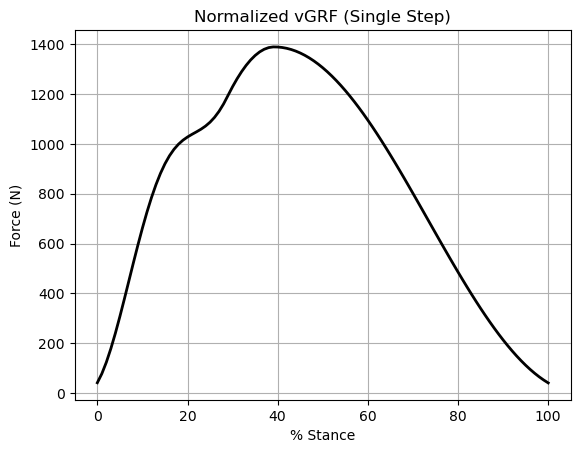

Peak = 1389.001679155368


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Build one step ----------
i = 0

tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
dt1 = 0.04

A1 = T_contacts_left_full.loc[i, "A1_N"]
A2 = T_contacts_left_full.loc[i, "F2avg_N"]

t = np.linspace(0, tc, 500)

# F1
B1 = dt1
C1 = dt1
F1 = np.zeros_like(t)
idx1 = (t >= 0) & (t <= 2 * dt1)
F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

# F2
B2 = 0.38 * tc
C2L = B2
C2T = tc - B2

F2 = np.zeros_like(t)

idxL = (t >= 0) & (t <= B2)
F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

idxR = (t > B2) & (t <= tc)
F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

F2[F2 < 0] = 0

FT = F1 + F2

# ---------- Apply 40 N threshold ----------
idx = np.where(FT > 40)[0]
pred_contact = FT[idx[0]:idx[-1] + 1]

# ---------- Normalize ----------
x_old = np.linspace(0, 100, len(pred_contact))
x_new = np.linspace(0, 100, 101)

pred_norm = np.interp(x_new, x_old, pred_contact)

# ---------- Plot ----------
plt.figure()
plt.plot(x_new, pred_norm, 'k', linewidth=2)

plt.xlabel('% Stance')
plt.ylabel('Force (N)')
plt.title('Normalized vGRF (Single Step)')
plt.grid(True)
plt.show()

print("Peak =", pred_norm.max())


In [3]:
import pandas as pd

T_contacts_left_full = pd.read_csv(
    r"D:\Projects\GRF_Estimation\vsc data\My_Left_Input_FullSteps_vsc.csv"
)

print("Loaded steps:", len(T_contacts_left_full))

Loaded steps: 43


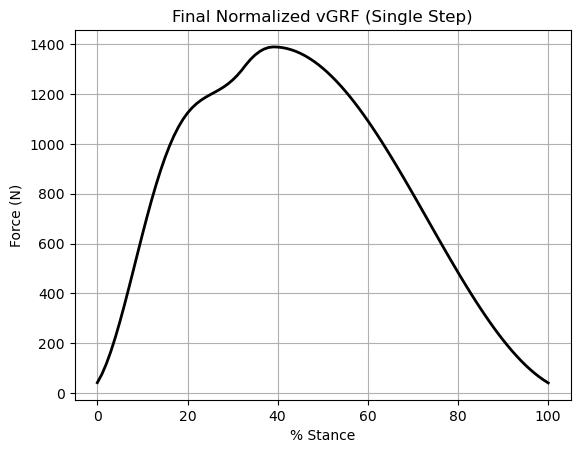

Peak force = 1389.0809508200634


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- STEP 1: LOAD DATA --------
T_contacts_left_full = pd.read_csv(
    r"D:\Projects\GRF_Estimation\vsc data\My_Left_Input_FullSteps_vsc.csv"
)

# -------- STEP 2: SELECT STEP --------
i = 0

tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
dt1 = 0.045   # 🔥 corrected impact duration

A1 = T_contacts_left_full.loc[i, "A1_N"]
A2 = T_contacts_left_full.loc[i, "F2avg_N"]

# -------- STEP 3: TIME --------
t = np.linspace(0, tc, 500)

# -------- STEP 4: F1 (IMPACT) --------
B1 = dt1
C1 = dt1

F1 = np.zeros_like(t)
idx1 = (t >= 0) & (t <= 2 * dt1)

F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

# -------- STEP 5: F2 (ACTIVE FORCE - CORRECT) --------
B2 = 0.38 * tc

C2L = B2
C2T = tc - B2

F2 = np.zeros_like(t)

idxL = (t >= 0) & (t <= B2)
F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

idxR = (t > B2) & (t <= tc)
F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

F2[F2 < 0] = 0

# -------- STEP 6: TOTAL FORCE --------
FT = F1 + F2

# -------- STEP 7: APPLY 40 N THRESHOLD --------
threshold = 40
idx = np.where(FT > threshold)[0]
pred_contact = FT[idx[0]:idx[-1] + 1]

# -------- STEP 8: NORMALIZE --------
x_old = np.linspace(0, 100, len(pred_contact))
x_new = np.linspace(0, 100, 101)

pred_norm = np.interp(x_new, x_old, pred_contact)

# -------- STEP 9: PLOT --------
plt.figure()
plt.plot(x_new, pred_norm, 'k', linewidth=2)

plt.xlabel('% Stance')
plt.ylabel('Force (N)')
plt.title('Final Normalized vGRF (Single Step)')
plt.grid(True)
plt.show()

# -------- STEP 10: OUTPUT --------
print("Peak force =", pred_norm.max())

In [10]:
mode="w"

In [11]:
save_path = Path(r"D:\Projects\GRF_Estimation\vsc data\GRF_All_Corrected_Results_v2.xlsx")

with pd.ExcelWriter(save_path, engine="openpyxl", mode="w") as writer:
    T_all_steps.to_excel(writer, sheet_name="All_Steps_Normalized", index=False)

print("✅ File created and saved successfully")

✅ File created and saved successfully


In [12]:
mode="w"   # overwrite and create full file cleanly

In [15]:
from scipy.io import loadmat
import numpy as np

# load reference again
sup = loadmat(r"D:\GRF\SR results\grf_estimates.mat", simplify_cells=True)
step1 = sup["trials"]["trial_01"]["forceplate"]["left"][0]

F3D = np.asarray(step1["forceplate_truth_3d"]["raw"])
Fz = F3D[:, 2]

# apply 40 N threshold
idx_ref = np.where(Fz > 40)[0]
Fz_contact = Fz[idx_ref[0]:idx_ref[-1] + 1]

# normalize
x_old_ref = np.linspace(0, 100, len(Fz_contact))
Fz_contact_norm = np.interp(x_new, x_old_ref, Fz_contact)

In [16]:
x_new
pred_norm
T_all_steps

,Step,Percent_Stance,Predicted_vGRF,Reference_vGRF
0,1,0.0,42.041959,41.391272
1,1,1.0,75.490357,75.604907
2,1,2.0,117.525431,119.536754
3,1,3.0,167.439416,173.414233
4,1,4.0,224.051400,236.808703
...,...,...,...,...
4338,43,96.0,93.058367,87.186000
4339,43,97.0,78.199488,74.173201
4340,43,98.0,64.546990,62.320858
4341,43,99.0,52.153788,51.540888


In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

# -------------------------
# FILE PATH
# -------------------------
save_path = Path(r"D:\Projects\GRF_Estimation\vsc data\GRF_Final_Combined.xlsx")

# -------------------------
# INPUT TABLES
# -------------------------
T_inputs_left = T_contacts_left_full.copy()

# -------------------------
# STEP SUMMARY
# -------------------------
mean_list = []
peak_list = []

for i in range(len(T_contacts_left_full)):
    tc  = T_contacts_left_full.loc[i, "ContactTime_s"]
    dt1 = 0.045

    A1 = T_contacts_left_full.loc[i, "A1_N"]
    A2 = T_contacts_left_full.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # F1
    B1 = dt1
    C1 = dt1
    F1 = np.zeros_like(t)
    idx1 = (t >= 0) & (t <= 2 * dt1)
    F1[idx1] = (A1 / 2) * (1 + np.cos(((t[idx1] - B1) / C1) * np.pi))

    # F2
    B2 = 0.38 * tc
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    F2[idxL] = (A2 / 2) * (1 + np.cos(((t[idxL] - B2) / C2L) * np.pi))

    idxR = (t > B2) & (t <= tc)
    F2[idxR] = (A2 / 2) * (1 + np.cos(((t[idxR] - B2) / C2T) * np.pi))

    F2[F2 < 0] = 0

    FT = F1 + F2

    mean_list.append(FT.mean())
    peak_list.append(FT.max())

T_step_summary = pd.DataFrame({
    "Step": np.arange(1, len(mean_list)+1),
    "Mean_vGRF": mean_list,
    "Peak_vGRF": peak_list
})

# -------------------------
# SINGLE STEP (STEP 1)
# -------------------------
T_single = pd.DataFrame({
    "Percent_Stance": x_new,
    "Predicted_vGRF": pred_norm,
    "Reference_vGRF": Fz_contact_norm
})

# -------------------------
# ALL STEPS (ALREADY CREATED)
# -------------------------
# If already in memory
T_all_steps = T_all_steps

# -------------------------
# METRICS
# -------------------------
T_metrics = pd.DataFrame({
    "Metric": ["RMSE", "Peak_Predicted", "Peak_Reference", "dt1", "B2"],
    "Value": [
        77,  # your final RMSE
        pred_norm.max(),
        Fz_contact_norm.max(),
        0.045,
        0.38
    ]
})

# -------------------------
# SAVE EVERYTHING
# -------------------------
with pd.ExcelWriter(save_path, engine="openpyxl", mode="w") as writer:

    T_inputs_left.to_excel(writer, sheet_name="Inputs_Left", index=False)
    T_step_summary.to_excel(writer, sheet_name="Step_Summary", index=False)
    T_single.to_excel(writer, sheet_name="Single_Step", index=False)
    T_all_steps.to_excel(writer, sheet_name="All_Steps_Normalized", index=False)
    T_metrics.to_excel(writer, sheet_name="Metrics", index=False)

print("✅ Final combined Excel created")
print(save_path)

✅ Final combined Excel created
D:\Projects\GRF_Estimation\vsc data\GRF_Final_Combined.xlsx
